In [18]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from time import perf_counter
import pandas
import pickle
import os
import keras
import tensorflow as tf
import sys
from module_utils import * 
sys.path.append('../utils')
from Structure3 import *

from data_collection import *
from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)



True

In [19]:
import itertools

# Define the intervals and number of points
num_points = 5  # Number of points in each linspace (adjust as needed)
# first_interval = np.linspace(2, 3.2, num_points)
# second_interval = np.linspace(0.6, 1.9, num_points)
# third_interval = np.linspace(0.6, 1.9, num_points)
# fourth_interval = np.linspace(0.8, 2.1, num_points)
first_interval = np.linspace(2.1, 3, num_points)
second_interval = np.linspace(0.9, 1.5, num_points)
third_interval = np.linspace(0.9, 1.5, num_points)
fourth_interval = np.linspace(1., 2.1, num_points)
# Generate all combinations using itertools.product
combinations = list(itertools.product(first_interval, second_interval, third_interval, fourth_interval))

# Convert the combinations to a numpy array
combinations_array = np.array(combinations)

# Shuffle the rows of the array
np.random.shuffle(combinations_array)

print(combinations_array)

[[3.    1.2   1.35  1.825]
 [2.325 0.9   1.35  1.55 ]
 [2.325 1.2   1.35  1.55 ]
 ...
 [3.    1.05  1.2   1.55 ]
 [2.325 1.2   1.5   1.275]
 [2.325 1.2   0.9   1.   ]]


In [20]:
combinations_array.shape

(625, 4)

In [21]:
# reproducibility
seed = 7
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

In [22]:
solver_HF = System2()
solver_LF = System2()

num_params=4
params=combinations_array[0:10,:]

(t_HF,y_HF,mu_HF)=solver_HF.generate_dataset(T=5.0, params=params, h=0.01, fidelity='HF')
solver_HF.save_dataset('dataset_HF_4params.h5')

(t_LF,y_LF,mu_LF)=solver_LF.generate_dataset(T=5.0, params=params, h=0.04, fidelity='LF')
solver_LF.save_dataset('dataset_LF_4params.h5')


In [23]:
len(y_HF)

10

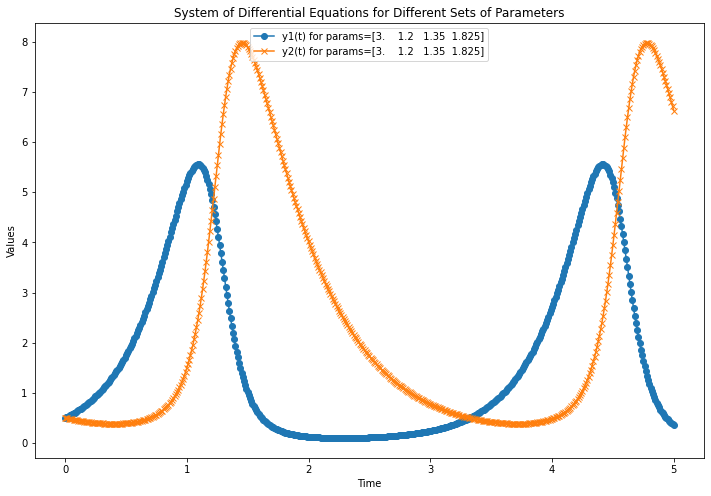

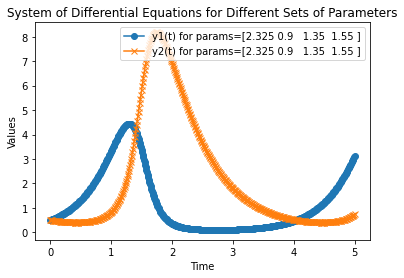

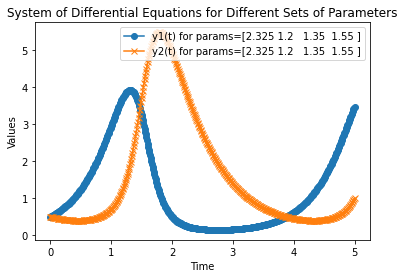

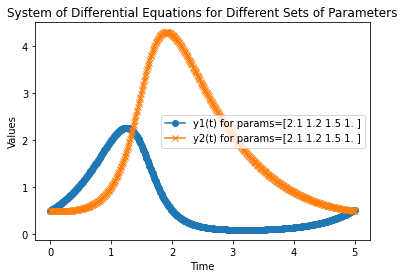

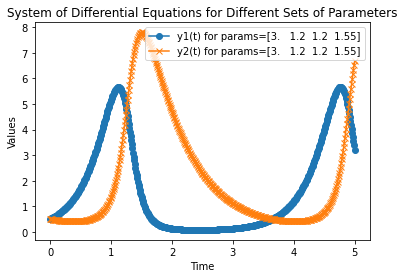

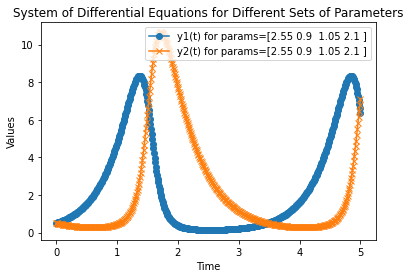

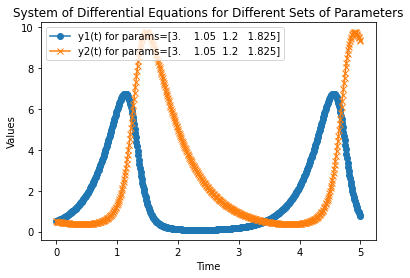

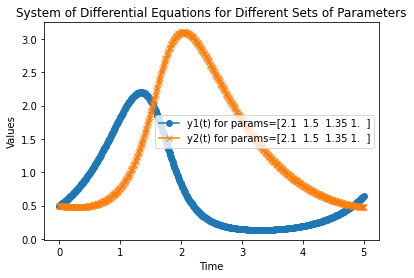

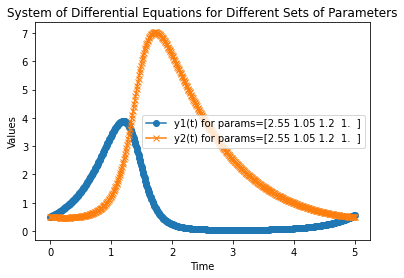

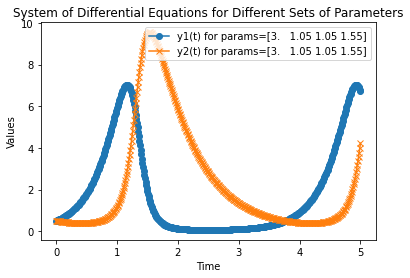

In [24]:
solver_HF.plot_results()

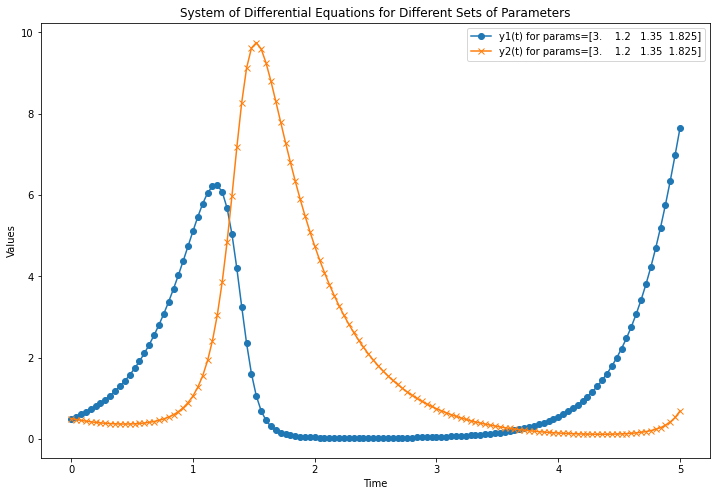

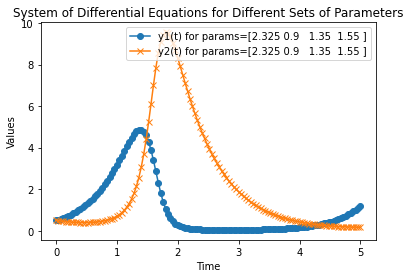

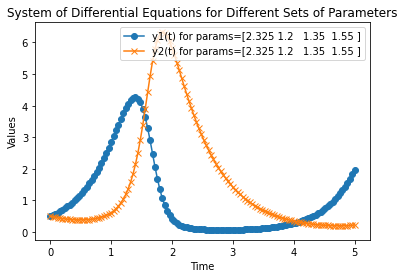

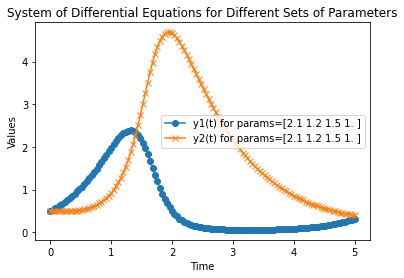

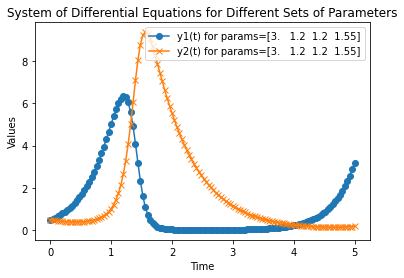

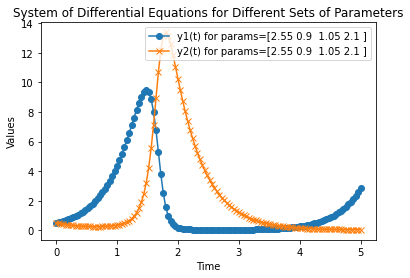

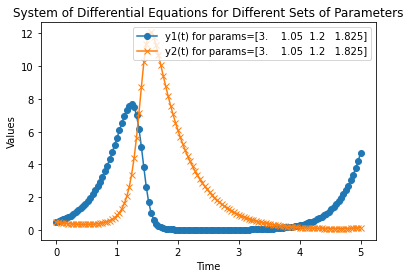

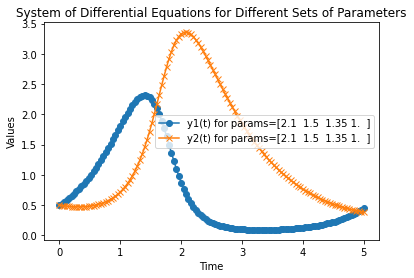

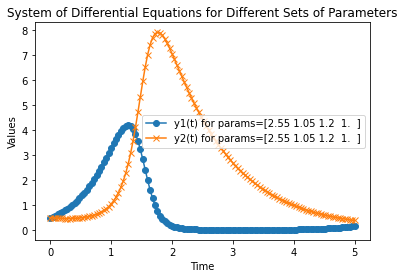

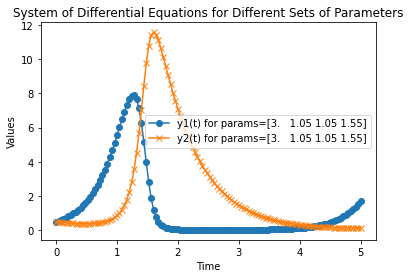

In [25]:
solver_LF.plot_results()

In [26]:
mu_HF.shape

(10, 4)

In [27]:
t_HF.shape

(501,)

In [28]:
t_HF.shape

(501,)

In [29]:
np.array(np.meshgrid(mu_HF,t_HF))#.T.reshape(-1, num_params+1)

array([[[3.  , 1.2 , 1.35, ..., 1.05, 1.05, 1.55],
        [3.  , 1.2 , 1.35, ..., 1.05, 1.05, 1.55],
        [3.  , 1.2 , 1.35, ..., 1.05, 1.05, 1.55],
        ...,
        [3.  , 1.2 , 1.35, ..., 1.05, 1.05, 1.55],
        [3.  , 1.2 , 1.35, ..., 1.05, 1.05, 1.55],
        [3.  , 1.2 , 1.35, ..., 1.05, 1.05, 1.55]],

       [[0.  , 0.  , 0.  , ..., 0.  , 0.  , 0.  ],
        [0.01, 0.01, 0.01, ..., 0.01, 0.01, 0.01],
        [0.02, 0.02, 0.02, ..., 0.02, 0.02, 0.02],
        ...,
        [4.98, 4.98, 4.98, ..., 4.98, 4.98, 4.98],
        [4.99, 4.99, 4.99, ..., 4.99, 4.99, 4.99],
        [5.  , 5.  , 5.  , ..., 5.  , 5.  , 5.  ]]])

In [30]:
# Create the Cartesian product of the indices
cartesian_product_indices = np.array(np.meshgrid(np.arange(mu_HF.shape[0]), np.arange(t_HF.shape[0]))).T.reshape(-1, 2)

# Extract the respective elements from the original vectors
x_HF = np.hstack((t_HF[cartesian_product_indices[:, 1]].reshape(-1, 1), mu_HF[cartesian_product_indices[:, 0]]))
#print(combined_vectors)


# Create the Cartesian product of the indices
cartesian_product_indices = np.array(np.meshgrid(np.arange(mu_LF.shape[0]), np.arange(t_LF.shape[0]))).T.reshape(-1, 2)

# Extract the respective elements from the original vectors
x_LF = np.hstack((t_LF[cartesian_product_indices[:, 1]].reshape(-1, 1), mu_LF[cartesian_product_indices[:, 0]]))


In [31]:
x_LF.shape

(1260, 5)

In [32]:
y_HF=np.array(y_HF).reshape(-1, solver_HF.get_dim())
y_LF=np.array(y_LF).reshape(-1, solver_LF.get_dim())

In [33]:
y_HF.shape

(5010, 2)

The function training took 13.022998 seconds.


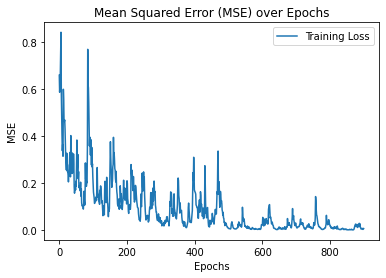

The function training took 133.541170 seconds.


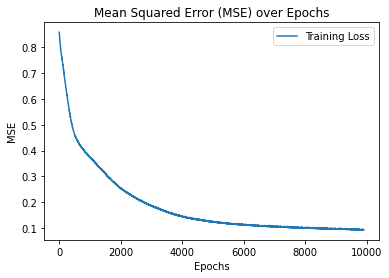

Test MSE: 0.30798920593788925
R^2: 0.9236059731218443


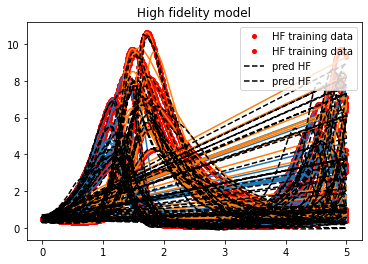

In [34]:
N=[1000,10000]
n=[500,1000]
names = ['LF', 'HF']

# parameters 
bestLF_params = {
    "lr": 0.0255,
    "kernel_init": "glorot_uniform",
    "opt": "Adam",
} 
best_params={'kernel_init': 'uniform', 'l2weight': 0.005395541657336886, 'lr': 0.0025412188591473228, 'nodes': 12.0, 'opt': 'Adamax'}

params_NN=[bestLF_params, best_params]


# collection of the parameters
definition_2steps = {
    "network_type": "2step",
    "names": names,
    "params": params_NN,
    "data_train": [x_LF,x_HF],
    "output_train": [y_LF, y_HF],
    "N": N,
    "n": n,
    "train": True,
    "do_HPO": False,
    "verbose": False
}

final_model = NetworkFactory.build_network(**definition_2steps)

solver_test=System2()
params_values_test = combinations_array[0:20,:]
(t_test,y_test,mu_test)=solver_test.generate_dataset(T=5.0, params=params_values_test, h=0.005, fidelity='HF')
solver_test.save_dataset('dataset_test_4params.h5')



# Create the Cartesian product of the indices
cartesian_product_indices = np.array(np.meshgrid(np.arange(mu_test.shape[0]), np.arange(t_test.shape[0]))).T.reshape(-1, 2)

# Extract the respective elements from the original vectors
datatest = np.hstack((t_test[cartesian_product_indices[:, 1]].reshape(-1, 1), mu_test[cartesian_product_indices[:, 0]]))
#print(combined_vectors)


y_test_pred=final_model.prediction(datatest)

(mse_MF,R_MF)=final_model.performance(datatest,np.array(y_test).reshape(-1,solver_test.get_dim()))


# Plotting data
plt.plot(x_HF[:, 0], y_HF, 'ro', label='HF training data', markersize=4)
plt.plot(datatest[:, 0], np.array(y_test).reshape(-1, 2))
plt.plot(datatest[:, 0], y_test_pred, 'k--', label='pred HF')

# Adding legend and title
plt.legend()
plt.title('High fidelity model')

# Show the plot
plt.show()

In [36]:
x_HF[:, 0].shape

(5010,)

In [37]:
y_HF.shape

(5010, 2)

In [49]:
parameters

array([2. , 0.6, 0.6, 0.8])

Sampling chain 1/2


Running chain, α = 0.08: 100%|██████████| 300/300 [00:47<00:00,  6.36it/s]


Sampling chain 2/2


Running chain, α = 0.09: 100%|██████████| 300/300 [00:54<00:00,  5.54it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\utils.py:187: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)


estimated values are [2.254 1.167 0.483 1.446]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.254  0.129   2.106    2.486      0.034    0.026      38.0      18.0   
x1  1.167  0.129   1.019    1.398      0.034    0.027      38.0      18.0   
x2  0.483  0.129   0.335    0.715      0.034    0.029      38.0      18.0   
x3  1.446  0.129   1.298    1.677      0.034    0.026      38.0      18.0   

    r_hat  
x0   1.31  
x1   1.31  
x2   1.31  
x3   1.31  


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\utils.py:187: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)


Autocorrelation...
The difference between estimated values [0.746 0.033 0.867 0.379]



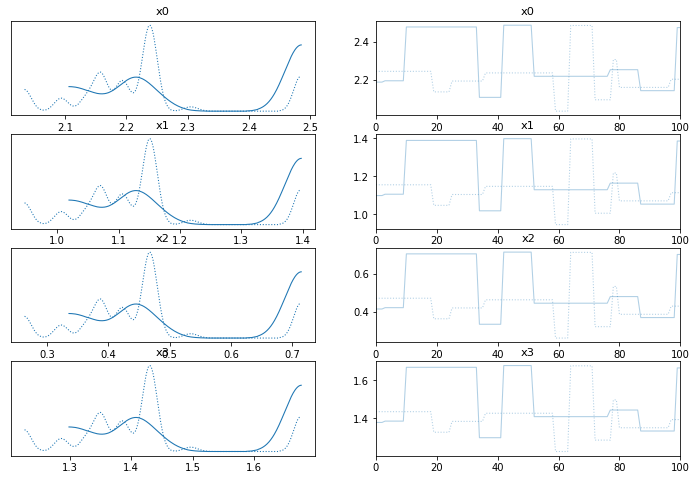

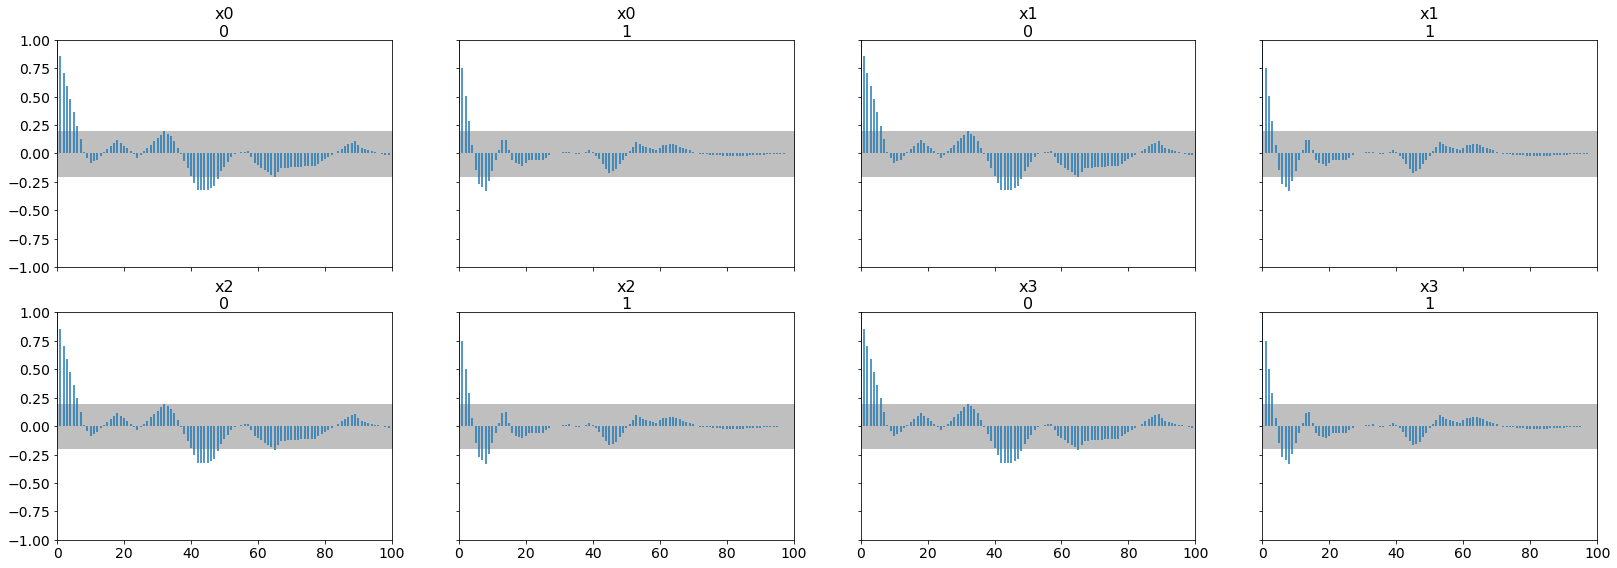

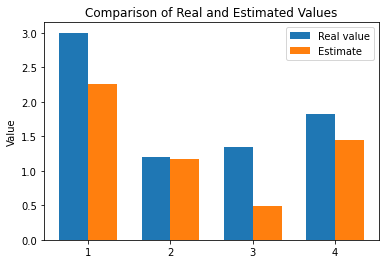

The function param_inverse took 147.789516 seconds.


ValueError: setting an array element with a sequence.

In [51]:
mean_prior =np.array([2.3,0.9,0.4,1.1])
cov_prior=np.diag([ 0.1, 0.01, 0.01, 0.1])

sigma_noise = [0.25,0.5]
n_data = [50,30]
parameters =np.array([3.,1.2,1.35,1.825])
sigma = np.array([ 4.,2.])
rwmh_scaling = np.array([ 2.,0.5,1.])
rwmh_cov = np.eye(1)
rwmh_adaptive = True
iterations = 300
burnin = 200
n_chains = 2
algo = "MH"


estimateMF, errorMF= run_simulation(x_HF, mean_prior, cov_prior, y_HF, sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, final_model,algo)
